In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rehanliaqat17/imbd-dataset/IMDB_Dataset.csv


In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith(".csv"):
            full_path = os.path.join(root, file)
            csv_files.append(full_path)
            print(full_path)

print("\nNumber of CSV files found:", len(csv_files))

/kaggle/input/datasets/rehanliaqat17/imbd-dataset/IMDB_Dataset.csv

Number of CSV files found: 1


In [5]:
imdb_files = [
    path for path in csv_files
    if "imdb" in os.path.basename(path).lower()
]

if len(imdb_files) == 0:
    raise FileNotFoundError(
        "IMDB CSV dataset was not found. "
        "Please attach the IMDB Dataset CSV to your Kaggle notebook."
    )

DATA_PATH = imdb_files[0]

print("Dataset selected:")
print(DATA_PATH)

# Load dataset
df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

# Display first 5 rows
display(df.head())

Dataset selected:
/kaggle/input/datasets/rehanliaqat17/imbd-dataset/IMDB_Dataset.csv

Dataset loaded successfully!
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Column names:
['review', 'sentiment']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sentiment percentage:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


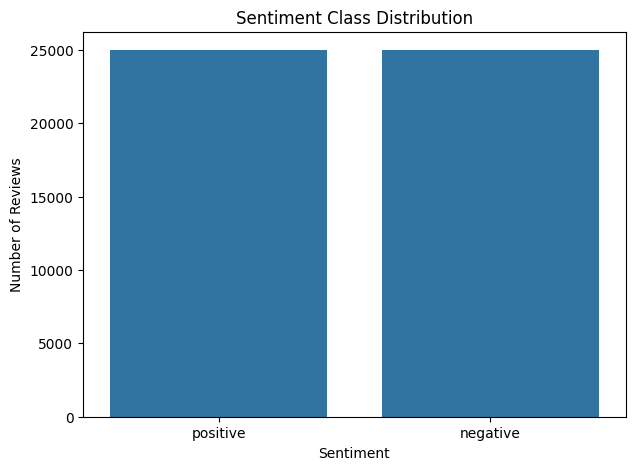


========== POSITIVE REVIEW ==========
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the ma

In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment percentage:")
print(df["sentiment"].value_counts(normalize=True) * 100)

# Plot sentiment distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

# Display positive and negative examples
print("\n========== POSITIVE REVIEW ==========")
print(df[df["sentiment"] == "positive"]["review"].iloc[0])

print("\n========== NEGATIVE REVIEW ==========")
print(df[df["sentiment"] == "negative"]["review"].iloc[0])

In [7]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags such as <br />
    text = re.sub(r"<br\s*/?>", " ", text)
    
    # Remove any remaining HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # Keep only alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# Apply cleaning
df["cleaned_review"] = df["review"].apply(clean_text)

print("Text preprocessing completed!")

# Compare original and cleaned text
display(
    df[["review", "cleaned_review"]].head()
)

Text preprocessing completed!


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [8]:
# Maximum number of words in vocabulary
VOCAB_SIZE = 10000

# Maximum sequence length
MAX_LENGTH = 200

# Tokenizer
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

# Build vocabulary
tokenizer.fit_on_texts(df["cleaned_review"])

# Convert text into integer sequences
sequences = tokenizer.texts_to_sequences(
    df["cleaned_review"]
)

print("Tokenization completed!")

print("Total unique words in tokenizer:",
      len(tokenizer.word_index))

print("\nFirst original review:")
print(df["cleaned_review"].iloc[0][:500])

print("\nFirst tokenized sequence:")
print(sequences[0][:30])

Tokenization completed!
Total unique words in tokenizer: 99421

First original review:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to t

First tokenized sequence:
[29, 5, 2, 78, 2038, 47, 1052, 12, 101, 150, 42, 3057, 395, 21, 230, 30, 3174, 33, 26, 205, 15, 11, 7, 614, 48, 593, 18, 69, 2, 89]


In [9]:
# Pad sequences
X = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Encode labels
y = df["sentiment"].map({
    "negative": 0,
    "positive": 1
}).values

print("Padding completed!")

print("\nInput shape:", X.shape)
print("Label shape:", y.shape)

print("\nExample padded sequence:")
print(X[0])

print("\nExample label:")
print(y[0])

print("\nLabel distribution:")
print(pd.Series(y).value_counts())

Padding completed!

Input shape: (50000, 200)
Label shape: (50000,)

Example padded sequence:
[  29    5    2   78 2038   47 1052   12  101  150   42 3057  395   21
  230   30 3174   33   26  205   15   11    7  614   48  593   18   69
    2   89  149   12 3219   69   45 3057   14   92 5325    3    1  136
    5  560   62  266    9  205   38    2  648  142 1724   69   11    7
   24    4  117   17    2 7806 2307   41    1   11  117 2571   57 5848
   18 5440    6 1456  372   41  560   92    7 3784    9    2  356  357
    5    2  648    8    7  433 3057   15   12    7    2    1  358    6
    2    1 6748 2516 1033    1    8 2686 1401   23    1  519   35 4619
 2437    5    2 1184  116   31    2 6928   28 2882    1    3  386    1
   37    1    7   24  298   23    2 4837 2886  519    7  341    6  108
    1 8060    1    1 4993 7689 2425    3   53   37    1  325 8984 7181
    1    3 8578    1   26  113  224  241   10   61  133    2  281 1320
    5    2  117    7  680    6    2  193   12    8  26

In [10]:
# First split:
# 80% training
# 20% temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Second split:
# 10% validation
# 10% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation data:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (40000, 200)
y_train: (40000,)

Validation data:
X_val: (5000, 200)
y_val: (5000,)

Testing data:
X_test: (5000, 200)
y_test: (5000,)


In [11]:
EMBEDDING_DIM = 128

print("Vocabulary size:", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)

# Create a temporary embedding model
embedding_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    )
])

# Generate embeddings for a small sample
sample_embeddings = embedding_model.predict(
    X_train[:5],
    verbose=0
)

print("\nEmbedding representation shape:")
print(sample_embeddings.shape)

print("\nEmbedding shape for one review:")
print(sample_embeddings[0].shape)

print("\nEmbedding generation completed!")

Vocabulary size: 10000
Embedding dimension: 128


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1790589914.699166      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790589914.702104      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Embedding representation shape:
(5, 200, 128)

Embedding shape for one review:
(200, 128)

Embedding generation completed!


I0000 00:00:1790589915.564718     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [12]:
model = Sequential([
    
    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),
    
    # LSTM layer
    LSTM(
        128,
        return_sequences=False
    ),
    
    # Dropout to reduce overfitting
    Dropout(0.5),
    
    # Output layer
    Dense(
        1,
        activation="sigmoid"
    )
])

# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

print("\nOptimizer: Adam")
print("Loss: Binary Cross-Entropy")
print("Metric: Accuracy")

Model compiled successfully!

Optimizer: Adam
Loss: Binary Cross-Entropy
Metric: Accuracy


In [14]:
EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\nModel training completed!")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.5383 - loss: 0.6853 - val_accuracy: 0.7100 - val_loss: 0.6083
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5878 - loss: 0.6702 - val_accuracy: 0.5898 - val_loss: 0.6640
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7138 - loss: 0.5660 - val_accuracy: 0.8172 - val_loss: 0.4569
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6288 - loss: 0.6457 - val_accuracy: 0.7204 - val_loss: 0.6209
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6896 - loss: 0.5917 - val_accuracy: 0.7896 - val_loss: 0.5283

Model training completed!


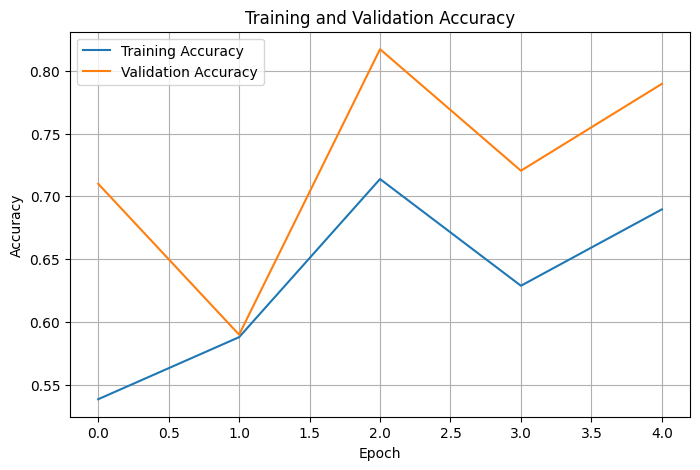

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

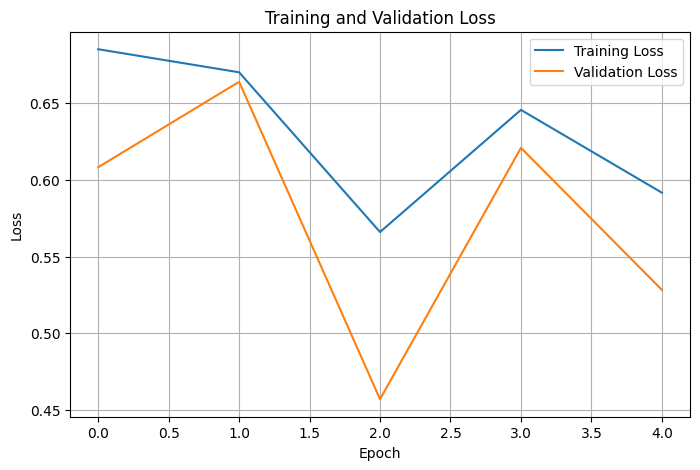

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTEST RESULTS")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7912 - loss: 0.5310

TEST RESULTS
Test Loss: 0.5310445427894592
Test Accuracy: 0.7911999821662903


In [18]:
# Predict probabilities
y_probability = model.predict(
    X_test,
    verbose=1
)

# Convert probabilities to classes
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")

print("\nFirst 20 predicted labels:")
print(y_pred[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Predictions generated successfully!

First 20 predicted labels:
[0 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1 1 1 1]

First 20 actual labels:
[0 1 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1]


In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("       MODEL EVALUATION RESULTS     ")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

       MODEL EVALUATION RESULTS     
Accuracy  : 0.7912
Precision : 0.7556
Recall    : 0.8608
F1-Score  : 0.8048


In [20]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.84      0.72      0.78      2500
    Positive       0.76      0.86      0.80      2500

    accuracy                           0.79      5000
   macro avg       0.80      0.79      0.79      5000
weighted avg       0.80      0.79      0.79      5000



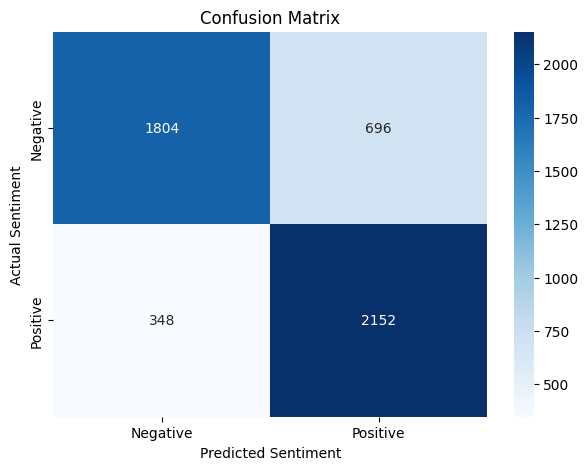

Confusion Matrix:
[[1804  696]
 [ 348 2152]]


In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

print("Confusion Matrix:")
print(cm)

In [22]:
sample_reviews = [
    "This movie was absolutely fantastic and I really enjoyed every minute of it.",
    
    "The movie was terrible, boring and a complete waste of time.",
    
    "The acting was excellent and the story was very interesting.",
    
    "I hated this movie because it was extremely slow and disappointing.",
    
    "An amazing film with great performances and a wonderful story."
]

# Clean sample reviews
cleaned_samples = [
    clean_text(review)
    for review in sample_reviews
]

# Convert to sequences
sample_sequences = tokenizer.texts_to_sequences(
    cleaned_samples
)

# Pad sequences
sample_padded = pad_sequences(
    sample_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# Predict
sample_probabilities = model.predict(
    sample_padded,
    verbose=0
).flatten()

# Display results
print("SAMPLE SENTIMENT PREDICTIONS")

for review, probability in zip(
    sample_reviews,
    sample_probabilities
):
    
    if probability >= 0.5:
        sentiment = "POSITIVE"
    else:
        sentiment = "NEGATIVE"
    
    print("Review:")
    print(review)
    print(f"Predicted Probability: {probability:.4f}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 70)

SAMPLE SENTIMENT PREDICTIONS
Review:
This movie was absolutely fantastic and I really enjoyed every minute of it.
Predicted Probability: 0.6479
Predicted Sentiment: POSITIVE
----------------------------------------------------------------------
Review:
The movie was terrible, boring and a complete waste of time.
Predicted Probability: 0.3591
Predicted Sentiment: NEGATIVE
----------------------------------------------------------------------
Review:
The acting was excellent and the story was very interesting.
Predicted Probability: 0.6524
Predicted Sentiment: POSITIVE
----------------------------------------------------------------------
Review:
I hated this movie because it was extremely slow and disappointing.
Predicted Probability: 0.3337
Predicted Sentiment: NEGATIVE
----------------------------------------------------------------------
Review:
An amazing film with great performances and a wonderful story.
Predicted Probability: 0.6815
Predicted Sentiment: POSITIVE
-----------------

In [23]:
comparison = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20]
})

# Convert numerical labels to text
comparison["Actual"] = comparison["Actual"].map({
    0: "Negative",
    1: "Positive"
})

comparison["Predicted"] = comparison["Predicted"].map({
    0: "Negative",
    1: "Positive"
})

display(comparison)

,Actual,Predicted
0,Negative,Negative
1,Positive,Positive
2,Positive,Positive
3,Negative,Negative
4,Negative,Negative
5,Negative,Negative
6,Negative,Positive
7,Negative,Negative
8,Positive,Positive
9,Negative,Positive


In [24]:
results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Test Loss",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    
    "Value": [
        history.history["accuracy"][-1],
        history.history["val_accuracy"][-1],
        test_accuracy,
        test_loss,
        precision,
        recall,
        f1
    ]
})

display(results)

print("LSTM SENTIMENT ANALYSIS COMPLETE")

print(f"Training Accuracy   : {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-Score            : {f1:.4f}")

,Metric,Value
0,Training Accuracy,0.689600
1,Validation Accuracy,0.789600
2,Test Accuracy,0.791200
3,Test Loss,0.531045
4,Precision,0.755618
5,Recall,0.860800
6,F1-Score,0.804787


LSTM SENTIMENT ANALYSIS COMPLETE
Training Accuracy   : 0.6896
Validation Accuracy : 0.7896
Test Accuracy       : 0.7912
Precision           : 0.7556
Recall              : 0.8608
F1-Score            : 0.8048
